In [6]:
import xarray as xr 
import numpy as np 
import pandas as pd
from importlib import reload 
import matplotlib.pyplot as plt
import plotting as pl 
import matplotlib.dates as mdates
from scipy import stats
from sklearn.cluster import KMeans
import anomaly_and_clustering as ac 
import sklearn as sk
import xeofs as xe

In [8]:
seas5_z500 = xr.open_dataset(r"C:\Users\rc831063\OneDrive - University of Reading\PhD\Data\SEAS5_processed\seas5_z500.nc",engine="netcdf4",decode_timedelta=False)
print(seas5_z500) # 'area': "80/ -90/ 20/ 30",

<xarray.Dataset> Size: 2GB
Dimensions:        (time: 44, number: 51, step: 151, latitude: 25, longitude: 49)
Coordinates:
  * time           (time) datetime64[ns] 352B 1981-11-01 ... 2024-11-01
  * number         (number) int32 204B 0 1 2 3 4 5 6 7 ... 44 45 46 47 48 49 50
  * step           (step) float64 1kB 0.0 24.0 48.0 ... 3.576e+03 3.6e+03
    valid_time     (time, step) datetime64[ns] 53kB ...
  * latitude       (latitude) float64 200B 80.0 77.5 75.0 ... 25.0 22.5 20.0
  * longitude      (longitude) float64 392B -90.0 -87.5 -85.0 ... 25.0 27.5 30.0
    isobaricInhPa  float64 8B ...
Data variables:
    z              (time, number, step, latitude, longitude) float32 2GB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    his

In [11]:
reload(ac)
seas5_djfm = seas5_z500.where(seas5_z500.valid_time.dt.month.isin([12,1,2,3]),drop=True)/9.80665 # convert geopotential to geopotential height (m)
seas5_anomaly = ac.compute_ensemble_linear_trend_anomaly(seas5_djfm, 'z')
# seas5_anomaly.to_netcdf('C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/ERA5_SEAS5_Anomaly_and_Clustering/Anomalies/SEAS5_z500_1981_2025_DJFM_daily_clim_linear_detrend_anomaly.nc')
seas5_anomaly

<xarray.DataArray (time: 44, number: 51, step: 121, latitude: 25, longitude: 49)> Size: 1GB
array([[[[[ 2.11790268e+02,  2.20795013e+02,  2.29695892e+02, ...,
           -3.49423904e+01, -4.14989243e+01, -4.72312622e+01],
          [ 1.50799545e+02,  1.66702560e+02,  1.83544693e+02, ...,
           -5.21629753e+01, -6.13422394e+01, -6.99000015e+01],
          [ 6.64388962e+01,  8.93737488e+01,  1.14612381e+02, ...,
           -6.18339081e+01, -7.12093964e+01, -8.06949615e+01],
          ...,
          [-5.03485680e+00, -2.94934120e+01, -5.12835274e+01, ...,
            5.31368141e+01,  5.56620827e+01,  5.31895714e+01],
          [ 9.59071255e+00, -3.78049207e+00, -1.59787521e+01, ...,
            4.07157364e+01,  4.36666946e+01,  4.32479210e+01],
          [ 1.24990005e+01,  5.03883457e+00, -3.48495531e+00, ...,
            3.16939373e+01,  3.39742317e+01,  3.43031883e+01]],

         [[ 2.37771393e+02,  2.46385330e+02,  2.54206833e+02, ...,
           -3.42314529e+01, -3.99938660e+01, -4.58218498e+01],
          [ 1.87054092e+02,  2.04465698e+02,  2.19947464e+02, ...,
           -1.18111923e+02, -1.21037560e+02, -1.23490631e+02],
          [ 9.47850952e+01,  1.23983383e+02,  1.50067108e+02, ...,
           -1.73850128e+02, -1.77040863e+02, -1.79429977e+02],
...
            8.07055969e+01,  8.74498215e+01,  9.19442368e+01],
          [ 1.75176067e+01,  1.64332466e+01,  1.42209206e+01, ...,
            6.74116516e+01,  7.01410294e+01,  7.13151703e+01],
          [ 2.03248215e+01,  1.86247559e+01,  1.60072479e+01, ...,
            5.18935852e+01,  5.12919235e+01,  5.03873711e+01]],

         [[ 3.49975548e+01,  3.58159294e+01,  3.52498245e+01, ...,
            4.38695564e+01,  4.62133446e+01,  4.89888153e+01],
          [-2.88343382e+00,  5.84655857e+00,  1.39850578e+01, ...,
           -1.11336451e+01, -1.07304392e+01, -9.24106598e+00],
          [-6.76603622e+01, -5.08020134e+01, -3.08010693e+01, ...,
           -7.13977432e+01, -7.40891647e+01, -7.48817062e+01],
          ...,
          [-2.90269012e+01, -3.15376720e+01, -3.08265858e+01, ...,
            7.51846161e+01,  7.89223557e+01,  8.21185455e+01],
          [-1.41852188e+01, -1.37527447e+01, -9.86273384e+00, ...,
            5.96567307e+01,  6.06196365e+01,  6.22870560e+01],
          [-4.37998915e+00, -3.55128765e+00, -1.15065372e+00, ...,
            4.37992058e+01,  4.34566956e+01,  4.41492233e+01]]]]],
      shape=(44, 51, 121, 25, 49), dtype=float32)
Coordinates:
  * time           (time) datetime64[ns] 352B 1981-11-01 ... 2024-11-01
  * number         (number) int32 204B 0 1 2 3 4 5 6 7 ... 44 45 46 47 48 49 50
  * step           (step) float64 968B 720.0 744.0 768.0 ... 3.576e+03 3.6e+03
  * latitude       (latitude) float64 200B 80.0 77.5 75.0 ... 25.0 22.5 20.0
  * longitude      (longitude) float64 392B -90.0 -87.5 -85.0 ... 25.0 27.5 30.0
    isobaricInhPa  float64 8B 500.0
    valid_time     (time, step) datetime64[ns] 43kB 1981-12-01 ... 2025-03-31
Attributes: (12/29)
    GRIB_paramId:                             129
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      1225
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_name:                                Geopotential
    GRIB_shortName:                           z
    GRIB_totalNumber:                         0
    GRIB_units:                               m**2 s**-2
    units:                                    m**2 s**-2

In [9]:
era5_z500 = xr.open_dataset(r"C:\Users\rc831063\OneDrive - University of Reading\PhD\Data\ERA5_500z\era5_z500_1940_2025.grib",engine="cfgrib",decode_timedelta=False)
era5_z500 # 'area': "80/ -90/ 20/ 30",

<xarray.Dataset> Size: 102MB
Dimensions:        (time: 20834, latitude: 25, longitude: 49)
Coordinates:
  * time           (time) datetime64[ns] 167kB 1940-01-01 ... 2025-12-31
    valid_time     (time) datetime64[ns] 167kB ...
  * latitude       (latitude) float64 200B 80.0 77.5 75.0 ... 25.0 22.5 20.0
  * longitude      (longitude) float64 392B -90.0 -87.5 -85.0 ... 25.0 27.5 30.0
    number         int64 8B ...
    step           float64 8B ...
    isobaricInhPa  float64 8B ...
Data variables:
    z              (time, latitude, longitude) float32 102MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-12T09:21 GRIB to CDM+CF via cfgrib-0.9.1...

In [10]:
reload(ac)
era5_z500_cropped = era5_z500.sel(time=slice('1981-11-01', '2025-03-31'))
era5_djfm = era5_z500_cropped.sel(time = era5_z500_cropped.time.dt.month.isin([12,1,2,3]))/9.80665
era5_anomaly = ac.compute_reanalysis_linear_trend_anomaly(era5_djfm, 'z')
# era5_anomaly.to_netcdf('C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/ERA5_SEAS5_Anomaly_and_Clustering/Anomalies/ERA5_z500_1940_2025_DJFM_daily_clim_linear_detrend_anomaly.nc')
era5_anomaly

Computing linear trend...


<xarray.DataArray (time: 5335, latitude: 25, longitude: 49)> Size: 52MB
array([[[ -14.81434708,  -14.6426606 ,  -15.86926586, ...,
          -93.80379168,  -90.20198563,  -84.67777961],
        [   1.11036308,   -2.7065381 ,   -6.74174573, ...,
         -100.21512385,  -93.92666307,  -87.04210247],
        [  -5.53337446,  -11.2050307 ,  -12.68294976, ...,
          -59.31559163,  -60.7338331 ,  -61.33239743],
        ...,
        [  -5.90640401,   -2.00834175,   -1.01470877, ...,
           26.29180997,   41.70634999,   54.76371362],
        [  -0.35363095,    0.52889893,   -0.38619665, ...,
           38.99696984,   47.16071221,   53.75983921],
        [  -2.18144019,   -1.00944848,   -0.34765016, ...,
           34.57290683,   38.25401126,   42.18704341]],

       [[ -56.93701862,  -53.18138372,  -51.09357638, ...,
          -93.72559921,  -96.72291472,  -97.95899132],
        [ -43.71682498,  -42.09630769,  -42.83617414, ...,
          -45.54517367,  -56.54725843,  -68.22179939],
        [ -34.09579781,  -35.89889177,  -39.17913771, ...,
            7.30770264,    3.69318492,   -1.07528779],
...
          -59.86925419,  -57.05239584,  -47.29588337],
        [ -17.92869596,  -15.70487044,  -12.12192862, ...,
          -36.14703482,  -32.91358685,  -28.02376105],
        [  -9.40051331,   -6.36876623,   -4.45281312, ...,
          -21.44413648,  -20.70883223,  -18.92200659]],

       [[  -0.56083479,   -4.93720817,   -8.68021335, ...,
           18.53403969,   20.08312541,   19.70698739],
        [  24.70748493,   16.95473626,    9.52725857, ...,
           58.13848917,   62.51017   ,   65.11447204],
        [  31.6240623 ,   18.6173435 ,    4.73836339, ...,
           86.25937798,   95.44521529,  101.11210474],
        ...,
        [   1.59506769,   -1.99283779,   -7.18971743, ...,
          -68.56855436,  -43.9831375 ,  -31.2466391 ],
        [  -6.8322561 ,  -11.82712112,  -13.73094257, ...,
          -36.1142052 ,  -26.24742865,  -17.55874966],
        [ -11.31020025,  -10.44584086,  -10.95902787, ...,
          -16.36514824,  -10.27874892,   -4.27118422]]],
      shape=(5335, 25, 49))
Coordinates:
  * time           (time) datetime64[ns] 43kB 1981-12-01 ... 2025-03-31
    number         (time) int64 43kB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
    step           (time) float64 43kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    isobaricInhPa  (time) float64 43kB 500.0 500.0 500.0 ... 500.0 500.0 500.0
    valid_time     (time) datetime64[ns] 43kB 1981-12-01 ... 2025-03-31
  * latitude       (latitude) float64 200B 80.0 77.5 75.0 ... 25.0 22.5 20.0
  * longitude      (longitude) float64 392B -90.0 -87.5 -85.0 ... 25.0 27.5 30.0
Attributes: (12/29)
    GRIB_paramId:                             129
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1225
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_name:                                Geopotential
    GRIB_shortName:                           z
    GRIB_totalNumber:                         0
    GRIB_units:                               m**2 s**-2
    units:                                    m**2 s**-2

In [30]:
reload(ac)

n_clusters = 6
tolerance = 1e-4
n_runs = 100
fit_months = [12, 1, 2, 3]
month_dict = {11: 'N', 12: 'D', 1: 'J', 2: 'F', 3: 'M'}
months_str = ''.join([month_dict[i] for i in fit_months])

ERA5_clusters = ac.kmeans_reanalysis(era5_anomaly, n_clusters, tolerance, n_runs, fit_months)
ERA5_clusters

fitting months [12, 1, 2, 3]
Check months being fit [ 1  2  3 12]


<xarray.Dataset> Size: 785kB
Dimensions:                (cluster: 6, latitude: 25, longitude: 49, time: 5335)
Coordinates:
  * cluster                (cluster) int64 48B 0 1 2 3 4 5
  * latitude               (latitude) float64 200B 80.0 77.5 75.0 ... 22.5 20.0
  * longitude              (longitude) float64 392B -90.0 -87.5 ... 27.5 30.0
  * time                   (time) datetime64[ns] 43kB 1981-12-01 ... 2025-03-31
Data variables:
    cluster_centres        (cluster, latitude, longitude) float64 59kB -43.5 ...
    assignments            (time) int32 21kB 5 5 5 5 5 5 4 4 ... 0 2 2 2 2 2 2 0
    amplitude_projections  (time, cluster) float64 256kB 558.3 -253.8 ... -679.2
    cosine_projections     (time, cluster) float64 256kB 0.1336 ... -0.1952
    distance_to_centres    (time, cluster) float32 128kB 4.371e+03 ... 4.559e+03
    min_distance           (time) float32 21kB 3.529e+03 3.241e+03 ... 2.901e+03

In [37]:
# ERA5_clusters.to_netcdf('C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/ERA5_SEAS5_Anomaly_and_Clustering/Clustering_and_EOF_Analysis/ERA5_6_clusters_1981_2025_DJFM_daily_clim_linear_detrend_anomaly_with_cosine_proj.nc')

In [38]:
reload(ac)
seas5_clusters = ac.assign_ensemble_forecast_to_reanalysis_clusters(seas5_anomaly, ERA5_clusters)
seas5_clusters

<xarray.Dataset> Size: 43MB
Dimensions:                (time: 44, number: 51, step: 121, cluster: 6)
Coordinates:
  * time                   (time) datetime64[ns] 352B 1981-11-01 ... 2024-11-01
  * number                 (number) int32 204B 0 1 2 3 4 5 ... 45 46 47 48 49 50
  * step                   (step) float64 968B 720.0 744.0 ... 3.576e+03 3.6e+03
  * cluster                (cluster) int64 48B 0 1 2 3 4 5
    valid_time             (time, step) datetime64[ns] 43kB 1981-12-01 ... 20...
Data variables:
    assignments            (time, number, step) int64 2MB 5 5 1 3 3 ... 5 0 0 1
    amplitude_projections  (time, number, step, cluster) float64 13MB -1.583e...
    cosine_projections     (time, number, step, cluster) float64 13MB -0.3623...
    distance_to_centres    (time, number, step, cluster) float64 13MB 5.395e+...
    min_distance           (time, number, step) float64 2MB 3.632e+03 ... 3.9...

In [39]:
# seas5_clusters.to_netcdf('C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/ERA5_SEAS5_Anomaly_and_Clustering/Clustering_and_EOF_Analysis/SEAS5_6_clusters_1981_2025_assigned_from_ERA5_1981_2025_DJFM_daily_clim_linear_detrend_anomaly_with_cosine_proj.nc')

# Plot the clusters

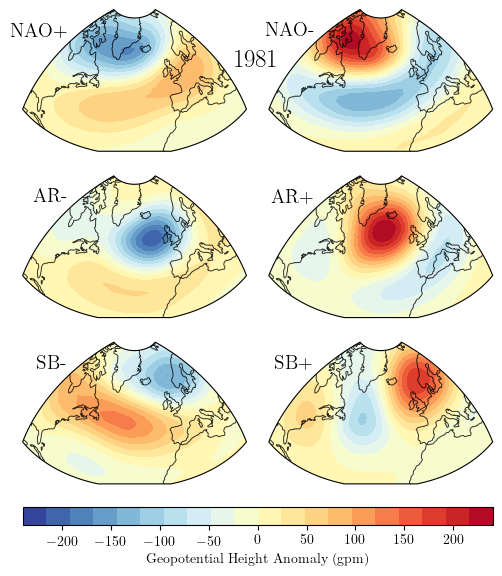

In [40]:
reload(pl)
cluster_order = [2,4,3,5,1,0]
cluster_names = ['NAO+','NAO-','AR-','AR+','SB-','SB+']
title='1981'

fig = pl.plot_cluster_centroids(ERA5_clusters, cluster_names, cluster_order, title=title)
# fig.savefig(f'C:/Users/rc831063/OneDrive - University of Reading/PhD/Figures/Clustering/Cluster Centres/ERA5_Kmeans_full_field_1940_2025_DJFM_fixed_anomaly_k6.pdf',bbox_inches='tight')
plt.show()

### EOF Analysis 

In [17]:
reload(ac)

model = ac.compute_era5_modes(era5_anomaly, n_modes=14)

eofs = model.components() 
seas5_pcs = ac.project_seas5_modes(seas5_anomaly, model, era5_anomaly)

# NAO (mode 1) and EAP (mode 2)
seas5_nao = seas5_pcs.sel(mode=1)
seas5_eap = seas5_pcs.sel(mode=2)

era5_pcs = model.scores()

In [18]:
# era5_pcs.drop_attrs().to_netcdf('C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/ERA5_SEAS5_Anomaly_and_Clustering/Clustering_and_EOF_Analysis/ERA5_EOF_z500_1940_2025_DJFM_daily_clim_linear_detrend_anomaly.nc')


In [19]:
# seas5_pcs.to_netcdf('C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/ERA5_SEAS5_Anomaly_and_Clustering/Clustering_and_EOF_Analysis/SEAS5_EOF_z500_1981_2025_from_ERA5_1940_2025_DJFM_daily_clim_linear_detrend_anomaly.nc')

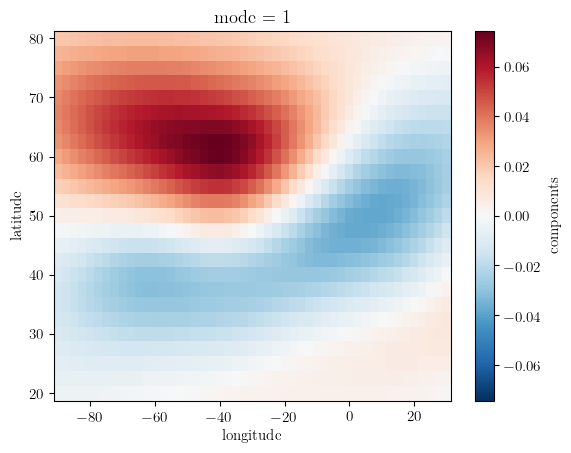

In [20]:
eofs.sel(mode=1).plot(cmap="RdBu_r")

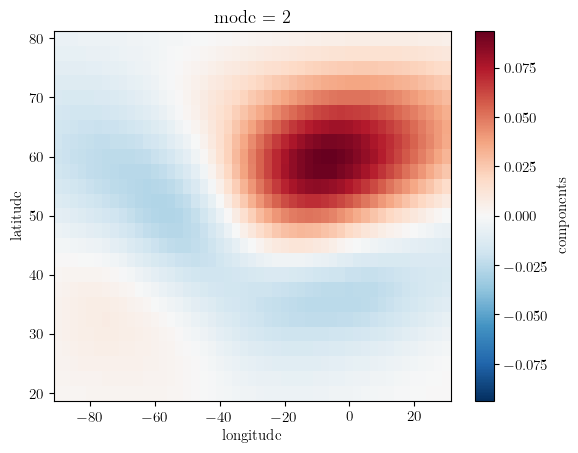

In [21]:
eofs.sel(mode=2).plot(cmap="RdBu_r")

In [16]:

era5_pcs_djfm_mask = era5_pcs.sel(time=era5_pcs.time.dt.month.isin([12, 1, 2, 3]))
winter_year = (era5_pcs_djfm_mask.time - pd.Timedelta(days=150)).dt.year
era5_pcs_djfm = era5_pcs_djfm_mask.assign_coords(winter=winter_year)
era5_pcs_djfm_mean = era5_pcs_djfm.groupby('winter').mean()

seas5_pcs_djfm_mask = seas5_pcs.valid_time.dt.month.isin([12, 1, 2, 3])
seas5_pcs_djfm_mean = seas5_pcs.where(seas5_pcs_djfm_mask).mean(dim='step', skipna=True)
seas5_pcs_djfm_ens_mean = seas5_pcs_djfm_mean.mean(dim='number')


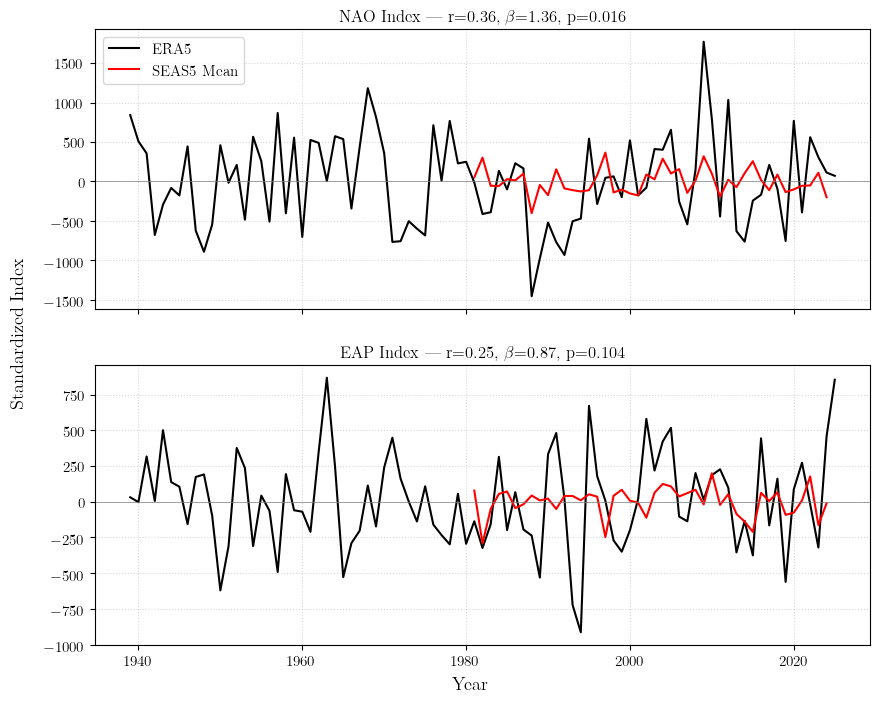

In [17]:
def plot_index_skill(era5_means, seas5_means, mode_names=['NAO', 'EAP']):
    """
    Plots time series and stats for PCA Modes.
    """
    # Prepare Data
    e_years = era5_means.winter.values
    s_years = seas5_means.time.dt.year.values # 1981, 1982...
    
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    
    for k, name in enumerate(mode_names):
        ax = axes[k]
        mode_idx = k + 1 # Modes are usually 1-based (1, 2)
        
        # Select Data
        e_series = era5_means.sel(mode=mode_idx).values
        s_series = seas5_means.sel(mode=mode_idx).values
        
        # --- Plotting ---
        ax.plot(e_years, e_series, color='black', linewidth=1.5, label='ERA5')
        ax.plot(s_years, s_series, color='red', linewidth=1.5, label='SEAS5 Mean')
        
        # --- Statistics ---
        common_years = np.intersect1d(e_years, s_years)
        
        if len(common_years) > 10:
            # Mask
            e_sub = era5_means.sel(winter=common_years, mode=mode_idx).values
            
            # SEAS5 selection
            mask_s = np.isin(s_years, common_years)
            s_sub = s_series[mask_s]
            
            # Stats
            slope, intercept, r_value, p_value, std_err = stats.linregress(s_sub, e_sub)
            stats_text = f"r={r_value:.2f}, $\\beta$={slope:.2f}, p={p_value:.3f}"
        else:
            stats_text = "Insufficient Overlap"
            
        # Format
        ax.set_title(f"{name} Index | {stats_text}", fontsize=12)
        ax.grid(True, linestyle=':', alpha=0.5)
        ax.axhline(0, color='gray', linewidth=0.5)
        
        if k == 0:
            ax.legend(loc='upper left')
            
    fig.supylabel('Standardized Index', x=0.04)
    fig.supxlabel('Year', y=0.05)
    return fig

fig = plot_index_skill(era5_pcs_djfm_mean, seas5_pcs_djfm_ens_mean)
plt.show()

# Fixed winter months analysis 

In [35]:
def compute_regression_stats(seas5_da, era5_da):
    """
    seas5_da: (time, number)
    era5_da:  (time)
    Returns: slope, r, r2, p
    """
    from scipy.stats import linregress

    # Ensemble mean first
    seas5_mean = seas5_da.mean(dim="number")

    y = era5_da.values
    x = seas5_mean.values

    mask = np.isfinite(x) & np.isfinite(y)

    if mask.sum() < 5:
        return np.nan, np.nan, np.nan, np.nan

    result = linregress(x[mask], y[mask])

    return result.slope, result.rvalue, result.rvalue**2, result.pvalue

In [41]:
era5_clusters = xr.open_dataset("C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/ERA5_SEAS5_Anomaly_and_Clustering/Clustering_and_EOF_Analysis/ERA5_6_clusters_1981_2025_DJFM_daily_clim_linear_detrend_anomaly_with_cosine_proj.nc", engine='netcdf4',decode_timedelta=False)
seas5_clusters = xr.open_dataset("C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/ERA5_SEAS5_Anomaly_and_Clustering/Clustering_and_EOF_Analysis/SEAS5_6_clusters_1981_2025_assigned_from_ERA5_1981_2025_DJFM_daily_clim_linear_detrend_anomaly_with_cosine_proj.nc", engine='netcdf4',decode_timedelta=False)
era5_eof = xr.open_dataset("C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/ERA5_SEAS5_Anomaly_and_Clustering/Clustering_and_EOF_Analysis/ERA5_EOF_z500_1940_2025_DJFM_daily_clim_linear_detrend_anomaly.nc", engine='netcdf4',decode_timedelta=False)
seas5_eof = xr.open_dataset("C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/ERA5_SEAS5_Anomaly_and_Clustering/Clustering_and_EOF_Analysis/SEAS5_EOF_z500_1981_2025_from_ERA5_1940_2025_DJFM_daily_clim_linear_detrend_anomaly.nc", engine='netcdf4',decode_timedelta=False)


In [45]:
winter_defs = {
    "DJFM": [12,1,2,3],
    "DJF": [12,1,2],
    # "JFM": [1,2,3],
    # "JF": [1,2],
    "Dec": [12],
    "Jan": [1],
    "Feb": [2],
    "Mar": [3],
}

linear_detrend_cluster_order = [2,4,3,5,1,0] # [2,0,3,5,1,4]
fixed_cluster_order = [2,1,4,5,3,0]
cluster_names = ['NAO+','NAO-','AR-','AR+','SB-','SB+']


results_ds = ac.compute_fixed_winter_month_metrics(
    era5_clusters,
    seas5_clusters,
    era5_eof.scores,
    seas5_eof.scores,
    winter_definitions=winter_defs,
    era5_cluster_order=linear_detrend_cluster_order,
    seas5_cluster_order=linear_detrend_cluster_order,
    cluster_names=cluster_names
)

results_ds

Computing DJFM
Computing DJF
Computing Dec
Computing Jan
Computing Feb
Computing Mar


<xarray.Dataset> Size: 2MB
Dimensions:           (winter: 6, cluster: 6, time: 44, number: 51, metric: 3,
                       stat: 4, mode: 2)
Coordinates:
  * winter            (winter) object 48B 'DJFM' 'DJF' 'Dec' 'Jan' 'Feb' 'Mar'
  * cluster           (cluster) <U4 96B 'NAO+' 'NAO-' 'AR-' 'AR+' 'SB-' 'SB+'
  * time              (time) datetime64[ns] 352B 1981-11-01 ... 2024-11-01
  * number            (number) int32 204B 0 1 2 3 4 5 6 ... 44 45 46 47 48 49 50
  * metric            (metric) <U10 120B 'frequency' 'projection' 'index'
  * stat              (stat) <U5 80B 'slope' 'r' 'r2' 'p'
  * mode              (mode) <U3 24B 'nao' 'eap'
    isobaricInhPa     float64 8B 500.0
Data variables:
    seas5_frequency   (winter, cluster, time, number) float64 646kB 0.3884 .....
    era5_frequency    (winter, cluster, time) float64 13kB 0.1405 ... 0.06452
    seas5_projection  (winter, time, number, cluster) float64 646kB 966.0 ......
    era5_projection   (winter, time, cluster) float64 13kB -471.6 ... 142.4
    seas5_index       (winter, time, number, cluster) float64 646kB 0.4329 .....
    era5_index        (winter, time, cluster) float32 6kB -0.2553 ... 0.3376
    seas5_nao         (winter, time, number) float64 108kB -770.8 ... -704.6
    era5_nao          (winter, time) float64 2kB -13.95 -412.0 ... 609.8 170.6
    seas5_eap         (winter, time, number) float64 108kB 645.1 ... -222.1
    era5_eap          (winter, time) float64 2kB -136.6 -323.1 ... -101.2 572.7
    regime_stats      (winter, metric, cluster, stat) float64 3kB 1.162 ... 0...
    eof_stats         (winter, mode, stat) float64 384B 1.366 0.3635 ... 0.5041

In [46]:
results_ds.drop_attrs().to_netcdf('C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/ERA5_SEAS5_Anomaly_and_Clustering/Segmentation_Stats/SEAS5_1981_2025_and_ERA5_1940_2025_DJFM_daily_clim_linear_detrend_anomaly_segment_mean_and_stats_v11.nc')


# ENSO calculation

In [62]:
era5_sst = xr.open_dataset("C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/ERA5_sst/ERA5_ENSO_sst_1940_2026.grib", engine='cfgrib',decode_timedelta=False)
era5_sst

<xarray.Dataset> Size: 14MB
Dimensions:     (time: 31472, latitude: 5, longitude: 21)
Coordinates:
  * time        (time) datetime64[ns] 252kB 1940-01-01 1940-01-02 ... 2026-03-01
  * latitude    (latitude) float64 40B 5.0 2.5 0.0 -2.5 -5.0
  * longitude   (longitude) float64 168B -170.0 -167.5 -165.0 ... -122.5 -120.0
    number      int64 8B ...
    step        float64 8B ...
    surface     float64 8B ...
    valid_time  (time) datetime64[ns] 252kB ...
Data variables:
    sst         (time, latitude, longitude) float32 13MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-29T10:40 GRIB to CDM+CF via cfgrib-0.9.1...

In [63]:
era5_enso34 = era5_sst.sel(time=era5_sst.time.dt.month.isin([11,12,1,2,3])).mean(dim=['latitude','longitude']).drop_vars(['number','step','surface'])


In [64]:
clim = era5_enso34.sel(time=era5_enso34.time.dt.month.isin([11,12,1])).mean(dim='time')
anom = era5_enso34 - clim

In [65]:
anom

<xarray.Dataset> Size: 261kB
Dimensions:     (time: 13068)
Coordinates:
  * time        (time) datetime64[ns] 105kB 1940-01-01 1940-01-02 ... 2026-03-01
    valid_time  (time) datetime64[ns] 105kB ...
Data variables:
    sst         (time) float32 52kB 0.6371 0.65 0.6709 ... 0.2215 0.2249 0.2408
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-29T10:40 GRIB to CDM+CF via cfgrib-0.9.1...

In [43]:
anom.to_netcdf("C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/ERA5_processed/ERA5_NINO34_daily_NDJFM_clim_NDJ_1940_2025.nc")

In [34]:
from xarray.groupers import SeasonResampler
anom_ndj = anom.sel(time=era5_enso34.time.dt.month.isin([11,12,1])).groupby(time=xr.groupers.SeasonResampler(['NDJ'], drop_incomplete=True)).mean()

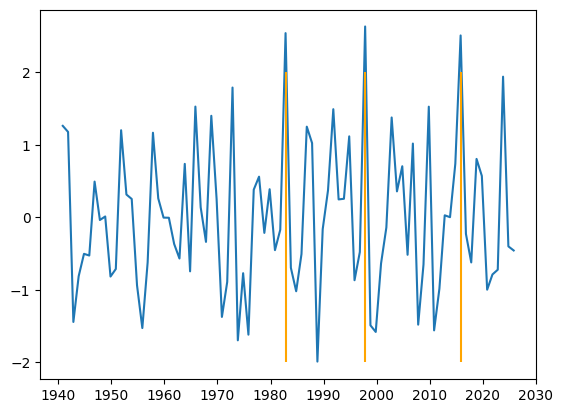

In [41]:
plt.plot(anom_ndj.time, anom_ndj.sst)
plt.vlines(['1982-11-01','1997-11-01','2015-11-01'],ymin=-2,ymax=2,colors='orange')
plt.show()

In [44]:
seas5_nino34 = xr.open_dataset("C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/SEAS5_ENSO34_sst/SEAS5_ENSO34_1981_2025_sst.nc",engine="netcdf4",decode_timedelta=False)
seas5_nino34

<xarray.Dataset> Size: 1MB
Dimensions:     (time: 44, number: 51, step: 151)
Coordinates:
  * time        (time) datetime64[ns] 352B 1981-11-01 1982-11-01 ... 2024-11-01
  * number      (number) int64 408B 0 1 2 3 4 5 6 7 ... 43 44 45 46 47 48 49 50
  * step        (step) float64 1kB 0.0 24.0 48.0 ... 3.552e+03 3.576e+03 3.6e+03
    surface     float64 8B ...
    valid_time  (time, step) datetime64[ns] 53kB ...
Data variables:
    sst         (time, number, step) float32 1MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-09-01T11:39 GRIB to CDM+CF via cfgrib-0.9.1...

In [51]:
seas5_nino34.valid_time.sel(step=24*91)

<xarray.DataArray 'valid_time' (time: 44)> Size: 352B
array(['1982-01-31T00:00:00.000000000', '1983-01-31T00:00:00.000000000',
       '1984-01-31T00:00:00.000000000', '1985-01-31T00:00:00.000000000',
       '1986-01-31T00:00:00.000000000', '1987-01-31T00:00:00.000000000',
       '1988-01-31T00:00:00.000000000', '1989-01-31T00:00:00.000000000',
       '1990-01-31T00:00:00.000000000', '1991-01-31T00:00:00.000000000',
       '1992-01-31T00:00:00.000000000', '1993-01-31T00:00:00.000000000',
       '1994-01-31T00:00:00.000000000', '1995-01-31T00:00:00.000000000',
       '1996-01-31T00:00:00.000000000', '1997-01-31T00:00:00.000000000',
       '1998-01-31T00:00:00.000000000', '1999-01-31T00:00:00.000000000',
       '2000-01-31T00:00:00.000000000', '2001-01-31T00:00:00.000000000',
       '2002-01-31T00:00:00.000000000', '2003-01-31T00:00:00.000000000',
       '2004-01-31T00:00:00.000000000', '2005-01-31T00:00:00.000000000',
       '2006-01-31T00:00:00.000000000', '2007-01-31T00:00:00.000000000',
       '2008-01-31T00:00:00.000000000', '2009-01-31T00:00:00.000000000',
       '2010-01-31T00:00:00.000000000', '2011-01-31T00:00:00.000000000',
       '2012-01-31T00:00:00.000000000', '2013-01-31T00:00:00.000000000',
       '2014-01-31T00:00:00.000000000', '2015-01-31T00:00:00.000000000',
       '2016-01-31T00:00:00.000000000', '2017-01-31T00:00:00.000000000',
       '2018-01-31T00:00:00.000000000', '2019-01-31T00:00:00.000000000',
       '2020-01-31T00:00:00.000000000', '2021-01-31T00:00:00.000000000',
       '2022-01-31T00:00:00.000000000', '2023-01-31T00:00:00.000000000',
       '2024-01-31T00:00:00.000000000', '2025-01-31T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time        (time) datetime64[ns] 352B 1981-11-01 1982-11-01 ... 2024-11-01
    step        float64 8B 2.184e+03
    surface     float64 8B ...
    valid_time  (time) datetime64[ns] 352B 1982-01-31 1983-01-31 ... 2025-01-31
Attributes:
    standard_name:  time
    long_name:      time

In [54]:
clim = seas5_nino34.sel(step=slice(0,24*91)).mean(dim=['time','step','number'])
anom = seas5_nino34 - clim
anom

<xarray.Dataset> Size: 1MB
Dimensions:     (number: 51, time: 44, step: 151)
Coordinates:
  * number      (number) int64 408B 0 1 2 3 4 5 6 7 ... 43 44 45 46 47 48 49 50
  * time        (time) datetime64[ns] 352B 1981-11-01 1982-11-01 ... 2024-11-01
  * step        (step) float64 1kB 0.0 24.0 48.0 ... 3.552e+03 3.576e+03 3.6e+03
    surface     float64 8B 0.0
    valid_time  (time, step) datetime64[ns] 53kB 1981-11-01 ... 2025-03-31
Data variables:
    sst         (time, number, step) float32 1MB -0.5109 -0.166 ... 0.4325
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-09-01T11:39 GRIB to CDM+CF via cfgrib-0.9.1...

In [56]:
anom.to_netcdf("C:/Users/rc831063/OneDrive - University of Reading/PhD/Data/SEAS5_processed/SEAS5_NINO34_daily_NDJFM_clim_NDJ_1981_2025.nc")

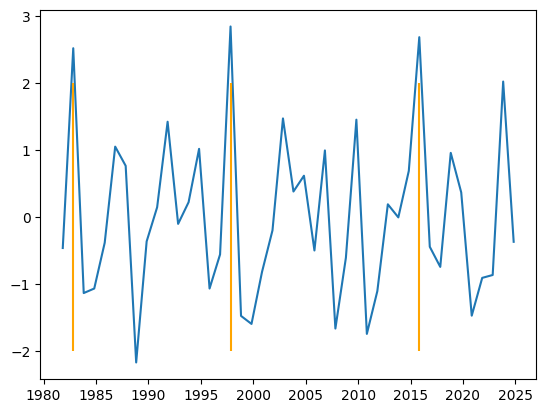

In [55]:
anom_ndj = anom.sel(step=slice(0,24*91)).mean(dim=['step','number'])
plt.plot(anom_ndj.time, anom_ndj.sst)
plt.vlines(['1982-11-01','1997-11-01','2015-11-01'],ymin=-2,ymax=2,colors='orange')
plt.show()